<a href="https://colab.research.google.com/github/geangontijo/dijkstra-cities/blob/main/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Shortest Route Finder - Brazilian Cities
## Dijkstra's Algorithm in Practice

A hands-on project implementing **Dijkstra's Algorithm** from scratch to find the shortest route between Brazilian cities.

Built as a study exercise based on the Dijkstra chapter from *Grokking Algorithms* (2nd edition).

---

## 1. Setup

Install the required libraries (only needed in Colab).

In [1]:
%pip install networkx matplotlib --quiet

In [2]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

## 2. Define the Graph

I'd model 15 Brazilian cities as nodes and the distances between them (in km) as weighted edges.

Each tuple represents: `(city_a, city_b, distance_km)`

In [3]:
EDGES = [
    ("Sao Paulo", "Rio de Janeiro", 430),
    ("Sao Paulo", "Belo Horizonte", 586),
    ("Sao Paulo", "Curitiba", 408),
    ("Rio de Janeiro", "Belo Horizonte", 434),
    ("Rio de Janeiro", "Vitoria", 521),
    ("Belo Horizonte", "Brasilia", 716),
    ("Belo Horizonte", "Vitoria", 524),
    ("Brasilia", "Goiania", 209),
    ("Brasilia", "Salvador", 1446),
    ("Curitiba", "Florianopolis", 300),
    ("Curitiba", "Porto Alegre", 711),
    ("Florianopolis", "Porto Alegre", 476),
    ("Goiania", "Cuiaba", 890),
    ("Salvador", "Recife", 839),
    ("Recife", "Fortaleza", 800),
    ("Fortaleza", "Belem", 1610),
    ("Belem", "Manaus", 5298),
    ("Goiania", "Sao Paulo", 926),
]

### Build the adjacency list

We convert the edge list into a dict where each city maps to its neighbors and distances:

```python
{"Sao Paulo": [("Rio de Janeiro", 430), ("Belo Horizonte", 586), ...], ...}
```

In [4]:
def build_graph(edges):
    graph = {}
    for city_a, city_b, distance in edges:
        graph.setdefault(city_a, []).append((city_b, distance))
        graph.setdefault(city_b, []).append((city_a, distance))
    return graph

graph = build_graph(EDGES)

# Preview: Sao Paulo's neighbors
print("Sao Paulo connects to:")
for neighbor, dist in graph["Sao Paulo"]:
    print(f"  -> {neighbor} ({dist} km)")

Sao Paulo connects to:
  -> Rio de Janeiro (430 km)
  -> Belo Horizonte (586 km)
  -> Curitiba (408 km)
  -> Goiania (926 km)


## 3. Dijkstra's Algorithm

The algorithm uses 4 data structures (mapped from *Grokking Algorithms* terminology):

| Grokking Algorithms | Our variable | Purpose |
|---|---|---|
| `costs` | `distances` | Cheapest known distance to each city from start |
| `parents` | `previous` | Which city led to the cheapest path |
| `processed` | `processed` | Set of already-explored cities |
| *(scan for cheapest)* | `heap` | Priority queue for efficient node selection |

### The loop in plain English:

1. **Pop** the cheapest unprocessed city from the heap
2. **Check** each of its neighbors: "is going through me cheaper than what you knew?"
3. If yes, **update** the neighbor's cost and record that we came from this city
4. **Mark** the city as processed
5. **Repeat** until we reach the destination

In [5]:
def dijkstra(graph, start, end):
    # STEP 1: Initialize data structures
    distances = {city: float("inf") for city in graph}
    distances[start] = 0

    previous = {}

    heap = [(0, start)]

    processed = set()

    # STEP 2: Main loop
    while heap:
        distance, city = heapq.heappop(heap)

        if city in processed:
            continue

        if city == end:
            break

        processed.add(city)

        for neighbor, weight in graph[city]:
            new_distance = distance + weight

            if new_distance < distances[neighbor]:
                distances[neighbor] = new_distance
                previous[neighbor] = city
                heapq.heappush(heap, (new_distance, neighbor))

    # STEP 3: Reconstruct path
    path = []
    city = end

    while city is not None:
        path.append(city)
        city = previous.get(city)

    path.reverse()

    if path[0] == start:
        return distances[end], path
    else:
        return float("inf"), []

## 4. Test It!

Let's find the shortest route from **Sao Paulo** to **Fortaleza**:

In [6]:
start = "Sao Paulo"
end = "Fortaleza"

distance, path = dijkstra(graph, start, end)

print(f"Shortest route from {start} to {end}:")
print(f"  Path: {' -> '.join(path)}")
print(f"  Total distance: {distance} km")

Shortest route from Sao Paulo to Fortaleza:
  Path: Sao Paulo -> Goiania -> Brasilia -> Salvador -> Recife -> Fortaleza
  Total distance: 4220 km


## 5. Visualization

The graph below shows all cities and connections. The **shortest path is highlighted in red**.

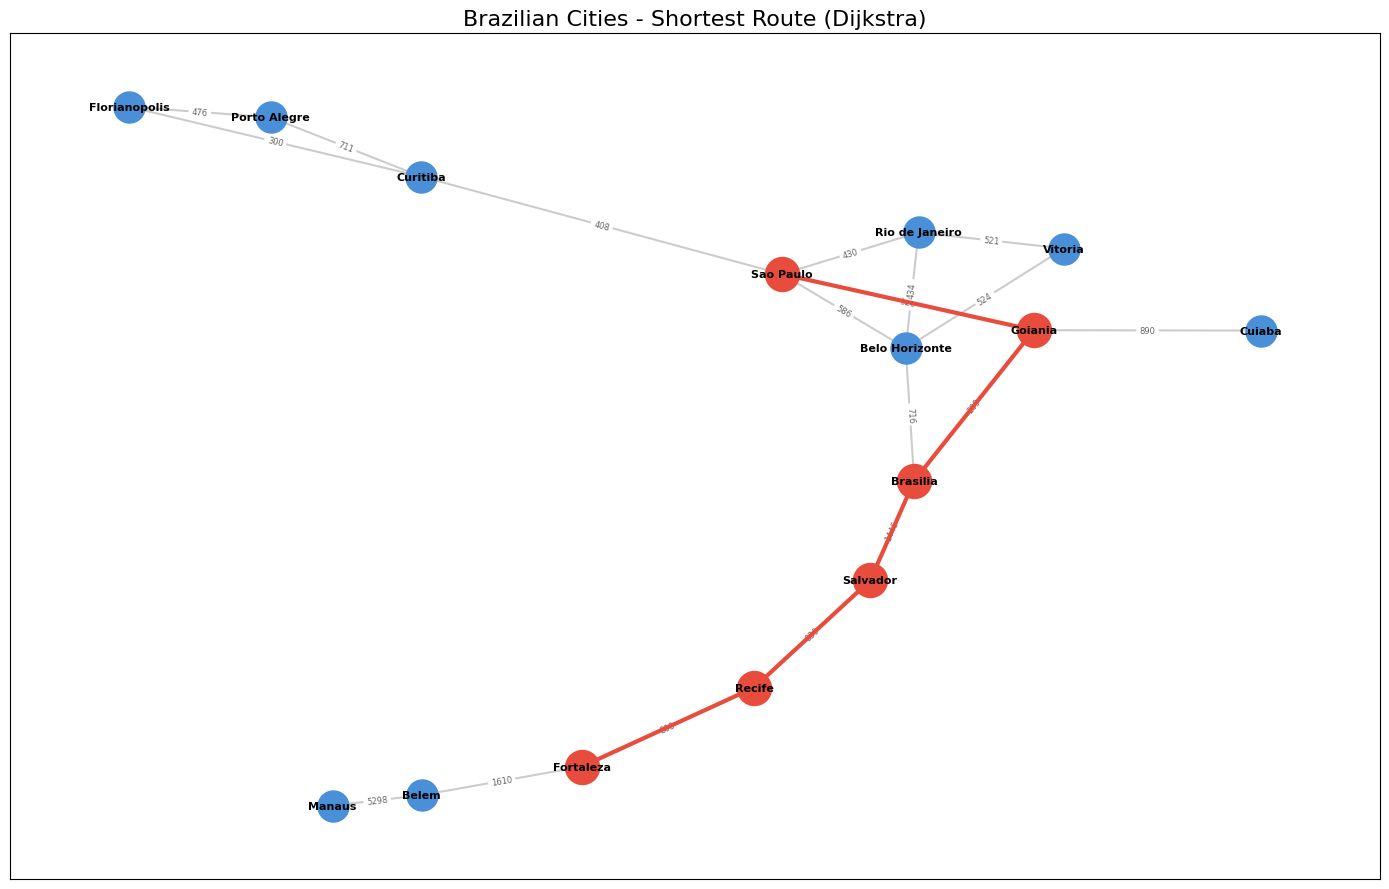

In [7]:
def visualize(graph, shortest_path=None):
    G = nx.Graph()

    for city, neighbors in graph.items():
        for neighbor, dist in neighbors:
            G.add_edge(city, neighbor, weight=dist)

    pos = nx.spring_layout(G, seed=42, k=2)

    plt.figure(figsize=(14, 9))
    plt.title("Brazilian Cities - Shortest Route (Dijkstra)", fontsize=16)

    nx.draw_networkx_edges(G, pos, edge_color="#cccccc", width=1.5)
    nx.draw_networkx_nodes(G, pos, node_color="#4a90d9", node_size=500)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")

    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=6, font_color="#666666")

    if shortest_path and len(shortest_path) > 1:
        path_edges = list(zip(shortest_path, shortest_path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="#e74c3c", width=3)
        nx.draw_networkx_nodes(G, pos, nodelist=shortest_path, node_color="#e74c3c", node_size=600)

    plt.tight_layout()
    plt.show()

visualize(graph, path)

## 6. Try it yourself!

Change `start` and `end` below to any of these cities and re-run:

> Belem, Belo Horizonte, Brasilia, Cuiaba, Curitiba, Florianopolis, Fortaleza, Goiania, Manaus, Porto Alegre, Recife, Rio de Janeiro, Salvador, Sao Paulo, Vitoria

Shortest route from Porto Alegre to Manaus:
  Path: Porto Alegre -> Curitiba -> Sao Paulo -> Goiania -> Brasilia -> Salvador -> Recife -> Fortaleza -> Belem -> Manaus
  Total distance: 12247 km



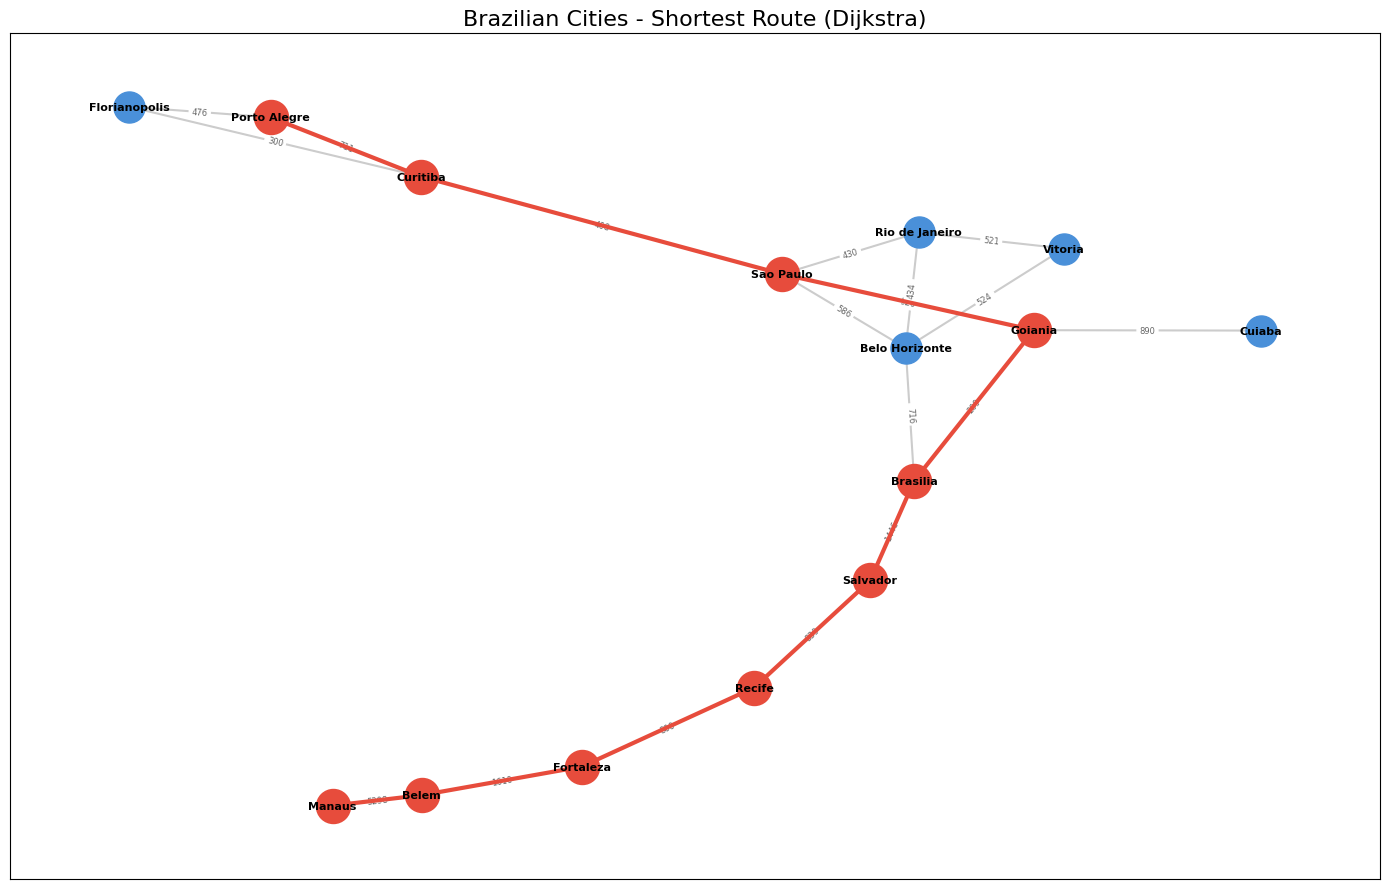

In [8]:
# Change these two cities and run this cell!
start = "Porto Alegre"
end = "Manaus"

distance, path = dijkstra(graph, start, end)

print(f"Shortest route from {start} to {end}:")
print(f"  Path: {' -> '.join(path)}")
print(f"  Total distance: {distance} km")
print()

visualize(graph, path)